# **Load cleaned dataset**

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

CLEANED_FILE = Path("/kaggle/input/datasets/ahsanrizvimeow/amazon-product-intelligence-cleaned/products_cleaned.json")

with open(CLEANED_FILE, encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Loaded {len(df)} products across {df['search_keyword'].nunique()} keywords")
display(df.head())

Loaded 1005 products across 28 keywords


,search_keyword,asin,title,brand,price_clean,price,price_was_imputed,rating,rating_missing,review_count,bullet_points,main_image_url,has_image,video_urls,reviews
0,wireless earbuds,B0D2HJDH94,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",Jxrev,19.99,19.99,False,4.3,False,16257.0,[13mm dynamic speakers for a richer audio expe...,https://m.media-amazon.com/images/I/619XqESa6I...,True,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'Maicha', 'rating': '5 out ..."
1,wireless earbuds,B09JYJ6JKH,"Neckband Bluetooth Headphones, 24H Playtime Wi...",YOSDOM,27.99,27.99,False,4.0,False,2856.0,[24 HOURS OF CONSECUTIVE PLAYBACK: You can use...,https://m.media-amazon.com/images/I/61BhENtK4I...,True,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'brsrafal', 'rating': '5 ou..."
2,wireless earbuds,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",XIAOWTEK,19.99,19.99,False,4.6,False,763.0,[LED Power Display and 50H Playback: Dual digi...,https://m.media-amazon.com/images/I/61odQgshCW...,True,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'diamela', 'rating': '5 out..."
3,wireless earbuds,B0H7R1LD7B,"HAOYUYAN Wireless Earbuds, Sports Bluetooth He...",HAOYUYAN,23.98,23.98,False,4.6,False,343.0,[【Sports Comfort & IPX7 Waterproof】BX17 Wirele...,https://m.media-amazon.com/images/I/71cmAChhQK...,True,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'Amazon Customer', 'rating'..."
4,wireless earbuds,B0G7H6K1WN,"Wireless Earbuds,Bluetooth 5.4 Ear buds,Sport ...",KTGEE,16.99,16.99,False,4.7,False,346.0,"[Secure & Comfortable Earhook Fit – Flexible, ...",https://m.media-amazon.com/images/I/71eD2UACLw...,True,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'Maggie Martin', 'rating': ..."


# **Explore data for Feature A**

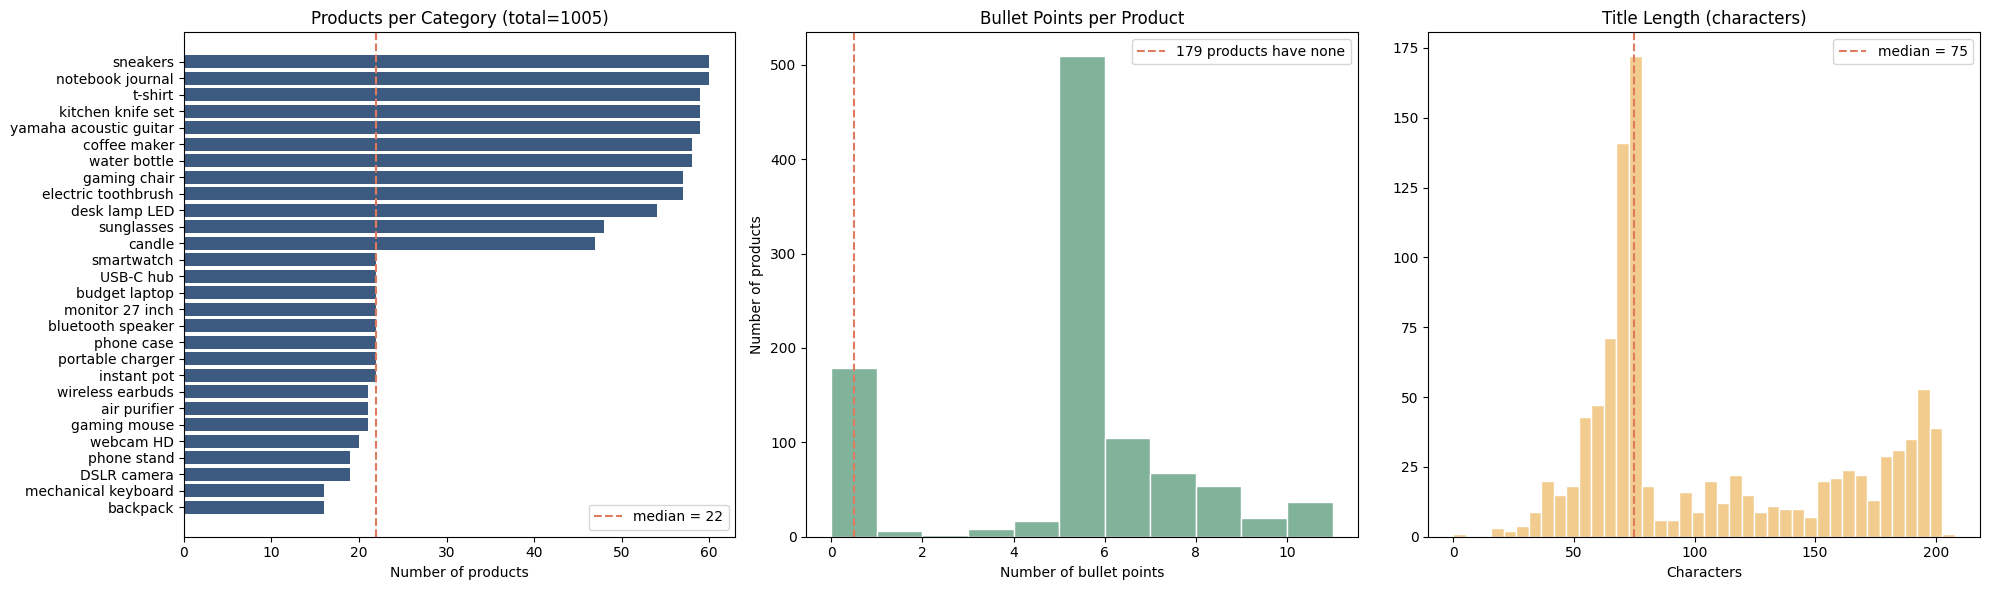

KEY FINDINGS FOR FEATURE A
Total products:            1005
Categories:                28
Largest category:          sneakers (60 products)
Smallest category:         mechanical keyboard (16 products)

Products with no bullets:  179 (17.8%)
Median bullets per product: 5
Median title length:        75 chars

Implication: titles are available for 100% of products and are
substantial (75 chars median), so they can carry similarity
on their own where bullets are missing.

SAMPLE: products with and without bullets


,search_keyword,asin,title,brand
81,smartwatch,B0GRWVNYPN,"WHOOP 5.0/MG Navigator Band, Rugged Outdoor Pe...",WHOOP
247,instant pot,B0HC3RNGYP,The Ultimate Instant Pot Cookbook for Beginner...,by Amy Delamore (Author) Format: Paperback
252,instant pot,B0GDKY82DD,Ultimate Instant Pot Recipes Cookbook with Pic...,by Lisa Fashoni (Author) Format: Paperback


,search_keyword,asin,title,brand
0,wireless earbuds,B0D2HJDH94,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",Jxrev
1,wireless earbuds,B09JYJ6JKH,"Neckband Bluetooth Headphones, 24H Playtime Wi...",YOSDOM
2,wireless earbuds,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",XIAOWTEK


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Products per keyword
kw_counts = df["search_keyword"].value_counts()
axes[0].barh(kw_counts.index, kw_counts.values, color="#3d5a80")
axes[0].set_title(f"Products per Category (total={len(df)})")
axes[0].set_xlabel("Number of products")
axes[0].invert_yaxis()
axes[0].axvline(kw_counts.median(), color="#e07a5f", linestyle="--",
                label=f"median = {kw_counts.median():.0f}")
axes[0].legend()

# 2. Bullet point availability
bullet_counts = df["bullet_points"].apply(len)
axes[1].hist(bullet_counts, bins=range(0, bullet_counts.max() + 2),
             color="#81b29a", edgecolor="white")
axes[1].set_title("Bullet Points per Product")
axes[1].set_xlabel("Number of bullet points")
axes[1].set_ylabel("Number of products")
axes[1].axvline(0.5, color="#e07a5f", linestyle="--",
                label=f"{(bullet_counts == 0).sum()} products have none")
axes[1].legend()

# 3. Title length distribution (fallback text source)
title_lengths = df["title"].str.len()
axes[2].hist(title_lengths, bins=40, color="#f2cc8f", edgecolor="white")
axes[2].set_title("Title Length (characters)")
axes[2].set_xlabel("Characters")
axes[2].axvline(title_lengths.median(), color="#e07a5f", linestyle="--",
                label=f"median = {title_lengths.median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

print("=" * 60)
print("KEY FINDINGS FOR FEATURE A")
print("=" * 60)
print(f"Total products:            {len(df)}")
print(f"Categories:                {df['search_keyword'].nunique()}")
print(f"Largest category:          {kw_counts.idxmax()} ({kw_counts.max()} products)")
print(f"Smallest category:         {kw_counts.idxmin()} ({kw_counts.min()} products)")
print(f"\nProducts with no bullets:  {(bullet_counts == 0).sum()} ({(bullet_counts == 0).sum()/len(df)*100:.1f}%)")
print(f"Median bullets per product: {bullet_counts.median():.0f}")
print(f"Median title length:        {title_lengths.median():.0f} chars")
print(f"\nImplication: titles are available for 100% of products and are")
print(f"substantial ({title_lengths.median():.0f} chars median), so they can carry similarity")
print(f"on their own where bullets are missing.")

print("\n" + "=" * 60)
print("SAMPLE: products with and without bullets")
print("=" * 60)
display(df[bullet_counts == 0][["search_keyword", "asin", "title", "brand"]].head(3))
display(df[bullet_counts > 0][["search_keyword", "asin", "title", "brand"]].head(3))

# **Detect Book-Like Brand Values**

In [3]:
book_pattern = df["brand"].str.contains(r"\(Author\)|Format:|Paperback|Hardcover|Kindle", case=False, na=False)
print(f"Products with book-like brand values: {book_pattern.sum()}")
display(df[book_pattern][["search_keyword", "asin", "title", "brand", "price"]])

print("\nAffected categories:")
display(df[book_pattern]["search_keyword"].value_counts())

Products with book-like brand values: 12


,search_keyword,asin,title,brand,price
247,instant pot,B0HC3RNGYP,The Ultimate Instant Pot Cookbook for Beginner...,by Amy Delamore (Author) Format: Paperback,5.99
252,instant pot,B0GDKY82DD,Ultimate Instant Pot Recipes Cookbook with Pic...,by Lisa Fashoni (Author) Format: Paperback,14.17
257,instant pot,B0G63LXZH1,The Latest Instant Pot Cookbook for Beginners:...,by Dorothy Milburn (Author) Format: Paperback,11.49
262,instant pot,B0DP38DKQM,The Ultimate Instant Pot Cookbook for Beginner...,by Jodi Gutierrez (Author) Format: Paperback,12.49
341,budget laptop,B0GM8RB7P7,"LaunchWise: A Step-by-Step System to Launch, O...",by Anastasia Nezhinsky (Author) Format: Paper...,13.99
723,notebook journal,B0B7CX57F4,My Dog's Journal: notebook,by Heather P Smith (Author) Format: Paperback,8.25
724,notebook journal,B0BPGKBLHV,COMPOSITION NOTEBOOK: MUSIC THEMED JOURNAL,by YESHA YAHU (Author) Format: Paperback,10.99
725,notebook journal,B0HCMZP9H1,HOMEWORK NOTEBOOK: FUN DESIGN HOMEWORK JOURNAL,by CAMMY CHANEY (Author) Format: Paperback,13.99
731,notebook journal,B0BSKN36HJ,COMPOSITION NOTEBOOK SCIENCE EQUATION THEMED: ...,by YESHA YAHU (Author) Format: Paperback,10.99
733,notebook journal,B0G4FH9ZZ7,Shadow Work Journal and Workbook – 7 in 1 Begi...,by Olivia K. Renner (Author) Format: Paperback,18.87



Affected categories:


search_keyword
notebook journal          6
instant pot               4
budget laptop             1
yamaha acoustic guitar    1
Name: count, dtype: int64

# **Normalize Book-Format Brand Names**

In [4]:
def extract_book_brand(brand):
    if not brand:
        return brand
    match = re.search(r"^by\s+(.+?)\s+(?:\(Author\)|Format:)", brand)
    if match:
        return match.group(1).strip()
    return brand

import re
df["brand"] = df["brand"].apply(extract_book_brand)

print("Cleaned book-format brands:")
display(df[df.index.isin([247, 252, 257, 262, 341, 723, 724, 725, 731, 733, 734, 956])][["asin", "title", "brand"]])

Cleaned book-format brands:


,asin,title,brand
247,B0HC3RNGYP,The Ultimate Instant Pot Cookbook for Beginner...,Amy Delamore
252,B0GDKY82DD,Ultimate Instant Pot Recipes Cookbook with Pic...,Lisa Fashoni
257,B0G63LXZH1,The Latest Instant Pot Cookbook for Beginners:...,Dorothy Milburn
262,B0DP38DKQM,The Ultimate Instant Pot Cookbook for Beginner...,Jodi Gutierrez
341,B0GM8RB7P7,"LaunchWise: A Step-by-Step System to Launch, O...",Anastasia Nezhinsky
723,B0B7CX57F4,My Dog's Journal: notebook,Heather P Smith
724,B0BPGKBLHV,COMPOSITION NOTEBOOK: MUSIC THEMED JOURNAL,YESHA YAHU
725,B0HCMZP9H1,HOMEWORK NOTEBOOK: FUN DESIGN HOMEWORK JOURNAL,CAMMY CHANEY
731,B0BSKN36HJ,COMPOSITION NOTEBOOK SCIENCE EQUATION THEMED: ...,YESHA YAHU
733,B0G4FH9ZZ7,Shadow Work Journal and Workbook – 7 in 1 Begi...,Olivia K. Renner


# **Build similarity text field**

In [5]:
def build_similarity_text(row):
    parts = [row["title"]]
    if row["brand"]:
        parts.append(row["brand"])
    if row["bullet_points"]:
        parts.extend(row["bullet_points"])
    return " ".join(parts)

df["similarity_text"] = df.apply(build_similarity_text, axis=1)

df["similarity_text_length"] = df["similarity_text"].str.len()

print("Similarity text length stats:")
display(df["similarity_text_length"].describe())

has_bullets = df["bullet_points"].apply(len) > 0
print(f"\nMedian text length WITH bullets:    {df[has_bullets]['similarity_text_length'].median():.0f} chars")
print(f"Median text length WITHOUT bullets: {df[~has_bullets]['similarity_text_length'].median():.0f} chars")

print("\nSample similarity_text (with bullets):")
print(df[has_bullets]["similarity_text"].iloc[0][:400])
print("\nSample similarity_text (no bullets):")
print(df[~has_bullets]["similarity_text"].iloc[0][:400])

Similarity text length stats:


count    1005.000000
mean     1258.931343
std       811.840114
min         0.000000
25%       642.000000
50%      1279.000000
75%      1777.000000
max      5106.000000
Name: similarity_text_length, dtype: float64


Median text length WITH bullets:    1461 chars
Median text length WITHOUT bullets: 78 chars

Sample similarity_text (with bullets):
Wireless Bluetooth 5.4 Earbuds, LED Power Display Headphones, 6D Stereo Jxrev 13mm dynamic speakers for a richer audio experience and ENC noise cancelling for clearer call: The larger driver delivers the Hi-Fi stereo sound with crisp, clear high notes and deep, rich bass. So with the ear buds wireless, you can enjoy more vivid sound than ever. Also, The built-in microphones in each eabud for calls

Sample similarity_text (no bullets):
WHOOP 5.0/MG Navigator Band, Rugged Outdoor Performance Accessory WHOOP


# **Visualize text length distribution**

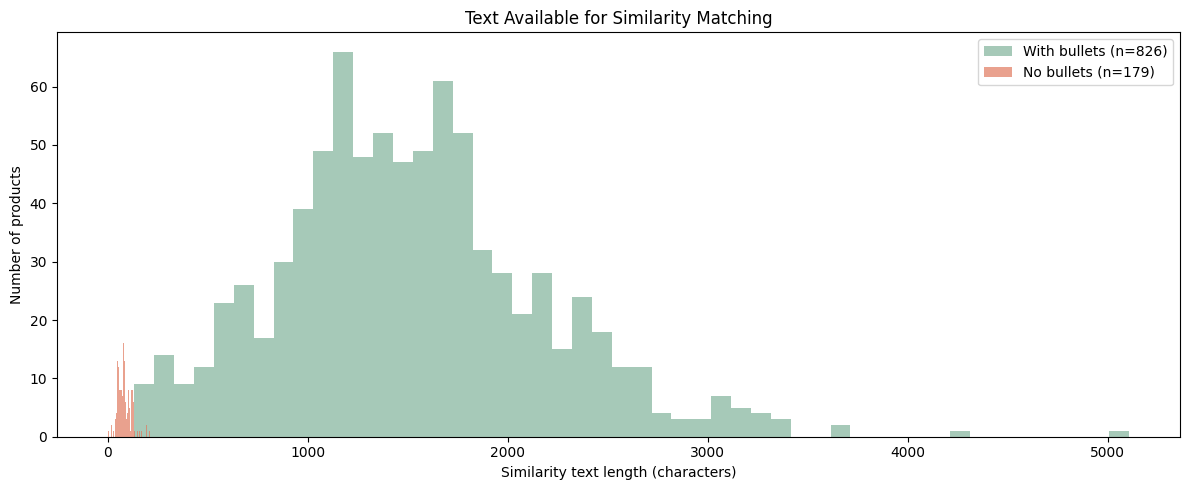

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df[has_bullets]["similarity_text_length"], bins=50, alpha=0.7,
        label=f"With bullets (n={has_bullets.sum()})", color="#81b29a")
ax.hist(df[~has_bullets]["similarity_text_length"], bins=50, alpha=0.7,
        label=f"No bullets (n={(~has_bullets).sum()})", color="#e07a5f")
ax.set_xlabel("Similarity text length (characters)")
ax.set_ylabel("Number of products")
ax.set_title("Text Available for Similarity Matching")
ax.legend()
plt.tight_layout()
plt.show()

# **Similarity Text Quality Check**

In [7]:
empty_text = df[df["similarity_text_length"] == 0]
print(f"Products with completely empty similarity text: {len(empty_text)}")
display(empty_text[["search_keyword", "asin", "title", "brand", "bullet_points"]])

print("\nShortest 10 similarity texts:")
display(df.nsmallest(10, "similarity_text_length")[["search_keyword", "asin", "title", "brand", "similarity_text_length"]])

Products with completely empty similarity text: 1


,search_keyword,asin,title,brand,bullet_points
810,sneakers,B000I9VON0,,,[]



Shortest 10 similarity texts:


,search_keyword,asin,title,brand,similarity_text_length
810,sneakers,B000I9VON0,,,0
794,sneakers,B0D31VM76T,On Womens Cloud 6,,17
787,sneakers,B0D5FYJBT9,Hoka Womens Bondi 9,,19
813,sneakers,B0C2JZMCPC,adidas Women's VL Court 3.0,,27
786,sneakers,B0B89H61L5,New Balance Women's 327,New Balance,35
814,sneakers,B07B3VQ8DY,New Balance Men's 608 V5,New Balance,36
806,sneakers,B073K417VQ,Cole Haan Grand Crosscourt II Sneaker,,37
812,sneakers,B08QBJTHM6,Nike Men's Air Force 1 '07 Sneaker,Nike,39
829,sneakers,B093QLCCWR,New Balance 574 Unisex Shoes,New Balance,40
809,sneakers,B0778XY3DT,Skechers Women's Summits Sneaker,Skechers,41


# **# CELL: Drop unusable product and finalize similarity text**

In [8]:
before = len(df)
df = df[df["similarity_text_length"] > 0].reset_index(drop=True)
print(f"Dropped {before - len(df)} product(s) with no usable text. Remaining: {len(df)}")


Dropped 1 product(s) with no usable text. Remaining: 1004


# **Build TF-IDF similarity model (baseline)**

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)
tfidf_matrix = tfidf.fit_transform(df["similarity_text"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")


TF-IDF matrix shape: (1004, 5000)
Vocabulary size: 5000


# **Build embedding similarity model (candidate)**

In [10]:
%pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(
    df["similarity_text"].tolist(),
    show_progress_bar=True,
    batch_size=32
)
print(f"Embedding matrix shape: {embeddings.shape}")


Note: you may need to restart the kernel to use updated packages.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding matrix shape: (1004, 384)


# **Similarity search function (works for both models)**

In [11]:
def find_similar(asin, matrix, top_n=5):
    """Return top_n most similar products within the same category."""
    if asin not in df["asin"].values:
        return None

    idx = df[df["asin"] == asin].index[0]
    keyword = df.loc[idx, "search_keyword"]

    same_category = df[df["search_keyword"] == keyword].index.tolist()
    same_category = [i for i in same_category if i != idx]

    query_vec = matrix[idx]
    if hasattr(query_vec, "reshape"):
        query_vec = query_vec.reshape(1, -1)

    scores = cosine_similarity(query_vec, matrix[same_category])[0]

    results = pd.DataFrame({
        "asin": df.loc[same_category, "asin"].values,
        "title": df.loc[same_category, "title"].values,
        "brand": df.loc[same_category, "brand"].values,
        "price": df.loc[same_category, "price"].values,
        "similarity": scores
    }).sort_values("similarity", ascending=False).head(top_n)

    return results

# **Compare TF-IDF vs embeddings on the same query**

In [12]:
test_asin = df[df["search_keyword"] == "wireless earbuds"]["asin"].iloc[0]
test_product = df[df["asin"] == test_asin].iloc[0]

print("=" * 70)
print(f"QUERY PRODUCT: {test_product['title'][:80]}")
print(f"Category: {test_product['search_keyword']} | Brand: {test_product['brand']} | ${test_product['price']}")
print("=" * 70)

print("\n--- TF-IDF results ---")
display(find_similar(test_asin, tfidf_matrix))

print("\n--- Embedding results ---")
display(find_similar(test_asin, embeddings))

QUERY PRODUCT: Wireless Bluetooth 5.4 Earbuds, LED Power Display Headphones, 6D Stereo
Category: wireless earbuds | Brand: Jxrev | $19.99

--- TF-IDF results ---


,asin,title,brand,price,similarity
9,B0H9LRGB3B,"Wireless Earbuds, Bluetooth 5.4 Ear Buds Bass ...",XIAOWTEK,19.99,0.630920
1,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",XIAOWTEK,19.99,0.624712
10,B0F4MZBZRH,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",Rolosar,22.99,0.602395
14,B0FHWGB7FW,"Wireless Earbuds, Bluetooth 5.4 Headphones Bas...",Btootos,22.79,0.564258
5,B0FLJYT87N,"Hupoaf Wireless Earbuds Sport, NEW Bluetooth 5...",Hupoaf,21.99,0.545390



--- Embedding results ---


,asin,title,brand,price,similarity
12,B0H8Y9LL1G,"Wireless Earbuds Bluetooth Headphones, 54H Pla...",TRAUSI,20.99,0.825119
14,B0FHWGB7FW,"Wireless Earbuds, Bluetooth 5.4 Headphones Bas...",Btootos,22.79,0.818011
13,B0H6ZWLNZ3,"Wireless Earbuds with Smart Touchscreen Case, ...",Bucephalus,16.99,0.813496
1,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",XIAOWTEK,19.99,0.807560
9,B0H9LRGB3B,"Wireless Earbuds, Bluetooth 5.4 Ear Buds Bass ...",XIAOWTEK,19.99,0.795222


# **Test on a category with short titles (stress test)**

In [13]:
test_asin_2 = df[df["search_keyword"] == "sneakers"]["asin"].iloc[5]
p2 = df[df["asin"] == test_asin_2].iloc[0]
print("=" * 70)
print(f"QUERY: {p2['title']} | {p2['brand']} | ${p2['price']}")
print("=" * 70)
print("\n--- TF-IDF ---")
display(find_similar(test_asin_2, tfidf_matrix))
print("\n--- Embeddings ---")
display(find_similar(test_asin_2, embeddings))

QUERY: New Balance Women's 574 Core Sneaker | New Balance | $85.95

--- TF-IDF ---


,asin,title,brand,price,similarity
41,B09YBLCL41,New Balance Women's 515 V3 Sneaker,New Balance,58.87,0.967947
13,B0B89H61L5,New Balance Women's 327,New Balance,104.95,0.917759
40,B07B3VQ8DY,New Balance Men's 608 V5,New Balance,59.99,0.884355
42,B09H3NJX44,New Balance Women's Fresh Foam Arishi V4,New Balance,58.87,0.866794
49,B0CMQLKP9J,New Balance Men's 480 V1 Sneakers,New Balance,84.19,0.846465



--- Embeddings ---


,asin,title,brand,price,similarity
41,B09YBLCL41,New Balance Women's 515 V3 Sneaker,New Balance,58.87,0.905180
55,B093QLCCWR,New Balance 574 Unisex Shoes,New Balance,58.87,0.770911
13,B0B89H61L5,New Balance Women's 327,New Balance,104.95,0.736524
23,B09XRGG5NV,New Balance Women's Fresh Foam Roav Running Shoe,New Balance,80.00,0.708208
49,B0CMQLKP9J,New Balance Men's 480 V1 Sneakers,New Balance,84.19,0.695001


# **Test on a product with NO bullet points (the 179 case)**

In [14]:
no_bullets = df[df["bullet_points"].apply(len) == 0]
test_asin_3 = no_bullets["asin"].iloc[0]
p3 = df[df["asin"] == test_asin_3].iloc[0]
print("=" * 70)
print(f"QUERY (no bullets): {p3['title']} | {p3['search_keyword']}")
print(f"Text length: {p3['similarity_text_length']} chars")
print("=" * 70)
print("\n--- TF-IDF ---")
display(find_similar(test_asin_3, tfidf_matrix))
print("\n--- Embeddings ---")
display(find_similar(test_asin_3, embeddings))

QUERY (no bullets): WHOOP 5.0/MG Navigator Band, Rugged Outdoor Performance Accessory | smartwatch
Text length: 71 chars

--- TF-IDF ---


,asin,title,brand,price,similarity
0,B0DY2SWV16,WHOOP 5.0/MG Activity Tracker - 12 Month Membe...,WHOOP,239.00,0.649731
16,B0CTCLBST5,"SAMSUNG Galaxy FIT 3 [2025, 40MM] 1.6"" AMOLED ...",,43.99,0.033012
14,B0DYF64BV2,XIAOMI Mi Smart Band 10 (2025) Global Version ...,XIAOMI,52.99,0.021951
18,B0F8QZ7233,"Garmin Forerunner® 970, 47mm, Carbon Gray DLC ...",,749.99,0.018761
15,B0CPLT23TZ,"Smart Watches for Men Android & iPhone, 1.8"" H...",Fitpolo,44.98,0.018592



--- Embeddings ---


,asin,title,brand,price,similarity
0,B0DY2SWV16,WHOOP 5.0/MG Activity Tracker - 12 Month Membe...,WHOOP,239.00,0.456291
1,B0HDN4SV8F,"Smart Watch for Men Women, 1.83"" HD Touchscree...",ganopterygon,19.95,0.350798
3,B0FWR4VJ87,"Smart Watch for Men Women (Answer/Make Call), ...",Coucur,14.99,0.347209
14,B0DYF64BV2,XIAOMI Mi Smart Band 10 (2025) Global Version ...,XIAOMI,52.99,0.336355
18,B0F8QZ7233,"Garmin Forerunner® 970, 47mm, Carbon Gray DLC ...",,749.99,0.320899


# **Score distribution comparison across all products**

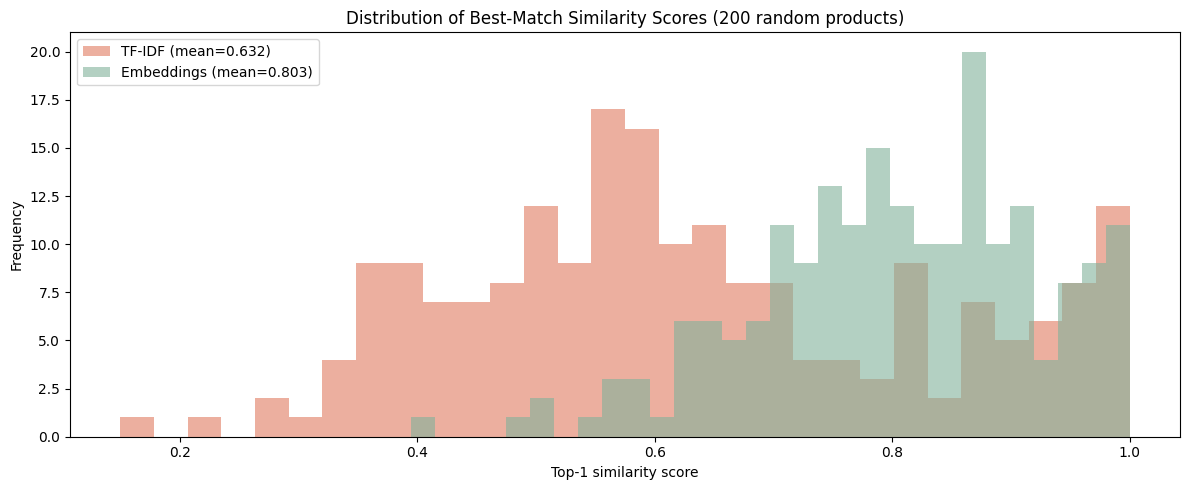

TF-IDF     — mean: 0.632, min: 0.150, max: 1.000
Embeddings — mean: 0.803, min: 0.394, max: 1.000


In [15]:
import numpy as np

def get_top_scores(matrix, n_samples=200):
    scores = []
    sample_indices = np.random.RandomState(42).choice(len(df), n_samples, replace=False)
    for idx in sample_indices:
        asin = df.loc[idx, "asin"]
        result = find_similar(asin, matrix, top_n=1)
        if result is not None and len(result) > 0:
            scores.append(result["similarity"].iloc[0])
    return scores

tfidf_scores = get_top_scores(tfidf_matrix)
emb_scores = get_top_scores(embeddings)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(tfidf_scores, bins=30, alpha=0.6, label=f"TF-IDF (mean={np.mean(tfidf_scores):.3f})", color="#e07a5f")
ax.hist(emb_scores, bins=30, alpha=0.6, label=f"Embeddings (mean={np.mean(emb_scores):.3f})", color="#81b29a")
ax.set_xlabel("Top-1 similarity score")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Best-Match Similarity Scores (200 random products)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"TF-IDF     — mean: {np.mean(tfidf_scores):.3f}, min: {np.min(tfidf_scores):.3f}, max: {np.max(tfidf_scores):.3f}")
print(f"Embeddings — mean: {np.mean(emb_scores):.3f}, min: {np.min(emb_scores):.3f}, max: {np.max(emb_scores):.3f}")

# **Similarity Evaluation & Hybrid Retrieval Benchmark**

In [16]:
# ============================================================
# CELL: Build hybrid similarity (normalized TF-IDF + embeddings)
# ============================================================
def find_similar_hybrid(asin, tfidf_weight=0.5, top_n=5):
    """Combine TF-IDF and embedding similarity with min-max normalization."""
    if asin not in df["asin"].values:
        return None

    idx = df[df["asin"] == asin].index[0]
    keyword = df.loc[idx, "search_keyword"]

    same_category = df[df["search_keyword"] == keyword].index.tolist()
    same_category = [i for i in same_category if i != idx]

    if len(same_category) == 0:
        return None

    tfidf_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix[same_category])[0]
    emb_scores = cosine_similarity(embeddings[idx].reshape(1, -1), embeddings[same_category])[0]

    def normalize(scores):
        lo, hi = scores.min(), scores.max()
        if hi - lo < 1e-9:
            return np.zeros_like(scores)
        return (scores - lo) / (hi - lo)

    hybrid = tfidf_weight * normalize(tfidf_scores) + (1 - tfidf_weight) * normalize(emb_scores)

    results = pd.DataFrame({
        "asin": df.loc[same_category, "asin"].values,
        "title": df.loc[same_category, "title"].values,
        "brand": df.loc[same_category, "brand"].values,
        "price": df.loc[same_category, "price"].values,
        "tfidf": tfidf_scores,
        "embedding": emb_scores,
        "hybrid": hybrid,
    }).sort_values("hybrid", ascending=False).head(top_n)

    return results


# ============================================================
# CELL: Sanity check hybrid on the two earlier test queries
# ============================================================
print("=" * 70)
print(f"QUERY: {p3['title']} (no bullets, smartwatch)")
print("=" * 70)
display(find_similar_hybrid(test_asin_3))

print("\n" + "=" * 70)
print(f"QUERY: {p2['title']} (sneakers)")
print("=" * 70)
display(find_similar_hybrid(test_asin_2))


# ============================================================
# CELL: Build evaluation sample (one query product per category)
# ============================================================
np.random.seed(42)
eval_queries = (df.groupby("search_keyword")
                  .apply(lambda g: g.sample(1, random_state=42))
                  .reset_index(drop=True))

print(f"Evaluation set: {len(eval_queries)} query products (1 per category)")
display(eval_queries[["search_keyword", "asin", "title", "brand", "price"]])


# ============================================================
# CELL: Generate all results for manual judging
# ============================================================
eval_rows = []
for _, q in eval_queries.iterrows():
    for method, matrix in [("tfidf", tfidf_matrix), ("embedding", embeddings)]:
        res = find_similar(q["asin"], matrix, top_n=5)
        if res is None:
            continue
        for rank, (_, r) in enumerate(res.iterrows(), 1):
            eval_rows.append({
                "query_asin": q["asin"],
                "query_title": q["title"][:60],
                "category": q["search_keyword"],
                "method": method,
                "rank": rank,
                "result_asin": r["asin"],
                "result_title": r["title"][:60],
                "score": round(r["similarity"], 3),
                "relevant": "",
            })

    hyb = find_similar_hybrid(q["asin"], top_n=5)
    if hyb is not None:
        for rank, (_, r) in enumerate(hyb.iterrows(), 1):
            eval_rows.append({
                "query_asin": q["asin"],
                "query_title": q["title"][:60],
                "category": q["search_keyword"],
                "method": "hybrid",
                "rank": rank,
                "result_asin": r["asin"],
                "result_title": r["title"][:60],
                "score": round(r["hybrid"], 3),
                "relevant": "",
            })

eval_df = pd.DataFrame(eval_rows)
print(f"Total result rows to judge: {len(eval_df)}")
print(f"Unique (query, result) pairs to actually read: {eval_df[['query_asin','result_asin']].drop_duplicates().shape[0]}")

eval_df.to_csv("/kaggle/working/similarity_eval_to_judge.csv", index=False)
print("\nSaved to /kaggle/working/similarity_eval_to_judge.csv")
display(eval_df.head(20))

QUERY: WHOOP 5.0/MG Navigator Band, Rugged Outdoor Performance Accessory (no bullets, smartwatch)


,asin,title,brand,price,tfidf,embedding,hybrid
0,B0DY2SWV16,WHOOP 5.0/MG Activity Tracker - 12 Month Membe...,WHOOP,239.00,0.649731,0.456291,1.000000
1,B0HDN4SV8F,"Smart Watch for Men Women, 1.83"" HD Touchscree...",ganopterygon,19.95,0.008712,0.350798,0.322421
3,B0FWR4VJ87,"Smart Watch for Men Women (Answer/Make Call), ...",Coucur,14.99,0.000000,0.347209,0.309448
14,B0DYF64BV2,XIAOMI Mi Smart Band 10 (2025) Global Version ...,XIAOMI,52.99,0.021951,0.336355,0.307380
18,B0F8QZ7233,"Garmin Forerunner® 970, 47mm, Carbon Gray DLC ...",,749.99,0.018761,0.320899,0.277925



QUERY: New Balance Women's 574 Core Sneaker (sneakers)


,asin,title,brand,price,tfidf,embedding,hybrid
41,B09YBLCL41,New Balance Women's 515 V3 Sneaker,New Balance,58.87,0.967947,0.905180,1.000000
13,B0B89H61L5,New Balance Women's 327,New Balance,104.95,0.917759,0.736524,0.842233
55,B093QLCCWR,New Balance 574 Unisex Shoes,New Balance,58.87,0.810144,0.770911,0.813525
49,B0CMQLKP9J,New Balance Men's 480 V1 Sneakers,New Balance,84.19,0.846465,0.695001,0.772946
23,B09XRGG5NV,New Balance Women's Fresh Foam Roav Running Shoe,New Balance,80.00,0.800753,0.708208,0.759657


Evaluation set: 28 query products (1 per category)


/tmp/ipykernel_58/1619256641.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1, random_state=42))


,search_keyword,asin,title,brand,price
0,DSLR camera,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,,499.00
1,USB-C hub,B0DT6Z3R4F,"Powered USB Hub 10Gbps, intpw 9-Port USB 3.2 H...",intpw,45.99
2,air purifier,B0H699TJC3,"DREO Air Purifier for Home, HEPA Sleep Mode, A...",DREO,69.98
3,backpack,B07CPW148Z,abshoo Classical Basic Womens Travel Backpack ...,abshoo,15.00
4,bluetooth speaker,B0C4BZ28PG,"Amazon Fire TV Soundbar, 2.0 speaker with DTS ...",Amazon Fire TV,59.97
5,budget laptop,B0GVPQNGS8,"dynabook Tecra A45-M 14” Business Laptop, AMD ...",dynabook,1209.00
6,candle,B099XVDV91,"Lulu Candles Jasmine, Oud & Sandalwood Scented...",Lulu Candles,36.95
7,coffee maker,B011WTM622,"ESPRO P3 French Press Coffee Maker, 32oz, Blac...",ESPRO,39.94
8,desk lamp LED,B0DDXYDSLM,"LED Desk Lamp with Clamp, 4CCT Table Lights fo...",SUNLINKCO,51.29
9,electric toothbrush,B0FN3S7LKG,"7MAGIC Sonic Electric Toothbrush, 180-Day Runt...",7MAGIC,20.99


Total result rows to judge: 420
Unique (query, result) pairs to actually read: 211

Saved to /kaggle/working/similarity_eval_to_judge.csv


,query_asin,query_title,category,method,rank,result_asin,result_title,score,relevant
0,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,tfidf,1,B0101RW3QK,Canon EOS Rebel T7 DSLR Camera Double Zoom Len...,0.866,
1,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,tfidf,2,B07PCSKGP7,Canon EOS Rebel T7 DSLR Camera with EF-S 18-55...,0.676,
2,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,tfidf,3,B0C5PGRP7V,Canon EOS R100 Mirrorless Camera RF-S18-45mm F...,0.487,
3,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,tfidf,4,B0BTTV6CT1,Canon EOS R50 Mirrorless Camera RF-S18-45mm F4...,0.464,
4,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,tfidf,5,B086TTTZR5,Canon EOS RP Full-Frame Mirrorless Interchange...,0.268,
5,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,embedding,1,B0101RW3QK,Canon EOS Rebel T7 DSLR Camera Double Zoom Len...,0.886,
6,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,embedding,2,B07PCSKGP7,Canon EOS Rebel T7 DSLR Camera with EF-S 18-55...,0.876,
7,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,embedding,3,B086TTTZR5,Canon EOS RP Full-Frame Mirrorless Interchange...,0.733,
8,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,embedding,4,B0C5PGRP7V,Canon EOS R100 Mirrorless Camera RF-S18-45mm F...,0.687,
9,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,embedding,5,B0BTTV6CT1,Canon EOS R50 Mirrorless Camera RF-S18-45mm F4...,0.672,


# **Export deduplicated pairs for judging**

In [17]:
unique_pairs = (eval_df[["query_asin", "query_title", "category",
                          "result_asin", "result_title"]]
                .drop_duplicates(subset=["query_asin", "result_asin"])
                .reset_index(drop=True))
unique_pairs["relevant"] = ""

print(f"Unique pairs to judge: {len(unique_pairs)}")
unique_pairs.to_csv("/kaggle/working/pairs_to_judge.csv", index=False)
print("Saved to /kaggle/working/pairs_to_judge.csv")
display(unique_pairs.head(10))

Unique pairs to judge: 211
Saved to /kaggle/working/pairs_to_judge.csv


,query_asin,query_title,category,result_asin,result_title,relevant
0,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,B0101RW3QK,Canon EOS Rebel T7 DSLR Camera Double Zoom Len...,
1,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,B07PCSKGP7,Canon EOS Rebel T7 DSLR Camera with EF-S 18-55...,
2,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,B0C5PGRP7V,Canon EOS R100 Mirrorless Camera RF-S18-45mm F...,
3,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,B0BTTV6CT1,Canon EOS R50 Mirrorless Camera RF-S18-45mm F4...,
4,B07C2Z21X5,Canon EOS Rebel T7 DSLR Camera EF-S 18-55mm f/...,DSLR camera,B086TTTZR5,Canon EOS RP Full-Frame Mirrorless Interchange...,
5,B0DT6Z3R4F,"Powered USB Hub 10Gbps, intpw 9-Port USB 3.2 H...",USB-C hub,B0G13RQ2SZ,ACASIS 16 Ports Powered USB 3.2 Hub (8 USB-A 3...,
6,B0DT6Z3R4F,"Powered USB Hub 10Gbps, intpw 9-Port USB 3.2 H...",USB-C hub,B0GLJ4P85L,"VANGREE Powered USB Hub,16 Ports 10Gbps USB C ...",
7,B0DT6Z3R4F,"Powered USB Hub 10Gbps, intpw 9-Port USB 3.2 H...",USB-C hub,B0G11F8FHR,Rosonway 7 Ports Powered USB 3.2/USB C Hub 10G...,
8,B0DT6Z3R4F,"Powered USB Hub 10Gbps, intpw 9-Port USB 3.2 H...",USB-C hub,B0BL9F5S6R,"VANGREE USB C Hub 8 in 1, 3 USB-C+3 USB-A 3.2 ...",
9,B0DT6Z3R4F,"Powered USB Hub 10Gbps, intpw 9-Port USB 3.2 H...",USB-C hub,B0F5HSNDXF,"Acer 10 Gbps USB C Hub, USBC Splitter with 4*U...",


# **Merge judgments and compute Precision@5**

In [19]:
JUDGED_FILE = "/kaggle/input/datasets/ahsanrizvimeow/suggestion-validation/pairs_judged.csv"
judged = pd.read_csv(JUDGED_FILE)

print(f"Loaded {len(judged)} judged pairs")
print(f"Relevant: {judged['relevant'].sum()} ({judged['relevant'].mean()*100:.1f}%)")

eval_scored = eval_df.drop(columns=["relevant"]).merge(
    judged[["query_asin", "result_asin", "relevant"]],
    on=["query_asin", "result_asin"],
    how="left"
)

unmatched = eval_scored["relevant"].isna().sum()
print(f"\nRows without a judgment (should be 0): {unmatched}")

precision_at_5 = (eval_scored.groupby(["method", "query_asin"])["relevant"]
                  .mean()
                  .reset_index(name="precision"))

summary = (precision_at_5.groupby("method")["precision"]
           .agg(["mean", "std", "min", "max"])
           .sort_values("mean", ascending=False))

print("\n" + "=" * 60)
print("PRECISION@5 BY METHOD")
print("=" * 60)
display(summary)

Loaded 211 judged pairs
Relevant: 170 (80.6%)

Rows without a judgment (should be 0): 0

PRECISION@5 BY METHOD


,mean,std,min,max
method,,,,
hybrid,0.864286,0.243758,0.2,1.0
tfidf,0.850000,0.241139,0.2,1.0
embedding,0.821429,0.268545,0.2,1.0


# **Visualize evaluation results**

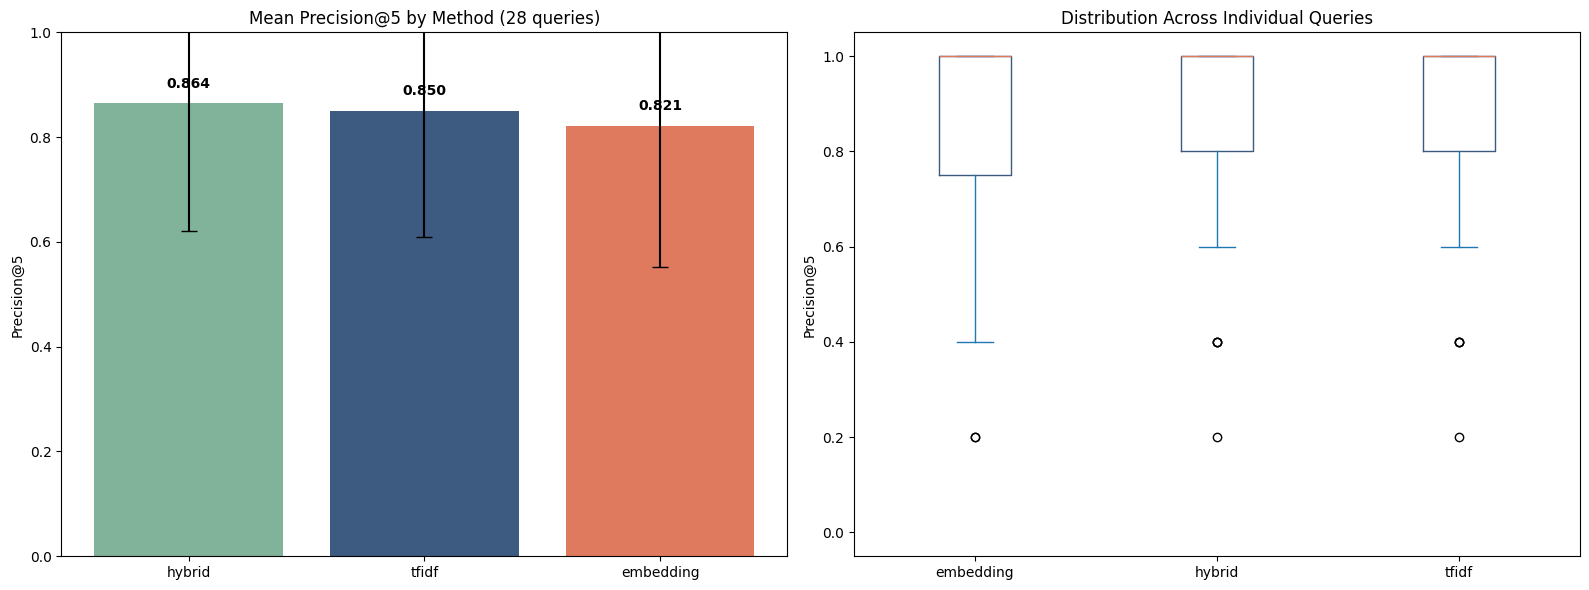


Per-category precision (worst 8):


method,embedding,hybrid,tfidf,avg
category,,,,
bluetooth speaker,0.2,0.2,0.2,0.200000
phone case,0.2,0.4,0.4,0.333333
coffee maker,0.4,0.4,0.4,0.400000
budget laptop,0.4,0.4,0.4,0.400000
smartwatch,0.4,0.6,0.8,0.600000
sneakers,0.6,0.6,0.6,0.600000
t-shirt,0.8,0.8,0.6,0.733333
DSLR camera,0.8,0.8,0.8,0.800000


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods = summary.index.tolist()
means = summary["mean"].values
stds = summary["std"].values

axes[0].bar(methods, means, yerr=stds, capsize=6,
            color=["#81b29a", "#3d5a80", "#e07a5f"])
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Mean Precision@5 by Method (28 queries)")
axes[0].set_ylim(0, 1)
for i, v in enumerate(means):
    axes[0].text(i, v + 0.03, f"{v:.3f}", ha="center", fontweight="bold")

pivot = precision_at_5.pivot(index="query_asin", columns="method", values="precision")
pivot.plot(kind="box", ax=axes[1], color=dict(boxes="#3d5a80", medians="#e07a5f"))
axes[1].set_ylabel("Precision@5")
axes[1].set_title("Distribution Across Individual Queries")
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("\nPer-category precision (worst 8):")
cat_map = eval_queries.set_index("asin")["search_keyword"]
precision_at_5["category"] = precision_at_5["query_asin"].map(cat_map)
worst = (precision_at_5.pivot(index="category", columns="method", values="precision")
         .assign(avg=lambda d: d.mean(axis=1))
         .sort_values("avg")
         .head(8))
display(worst)

# **Generate similarity reasons**

In [26]:
def get_top_shared_terms(idx_a, idx_b, top_n=3):
    """Find the highest-weighted TF-IDF terms shared by two products."""
    feature_names = np.array(tfidf.get_feature_names_out())
    vec_a = tfidf_matrix[idx_a].toarray()[0]
    vec_b = tfidf_matrix[idx_b].toarray()[0]

    shared = np.minimum(vec_a, vec_b)
    if shared.sum() == 0:
        return []
    top_indices = shared.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in top_indices if shared[i] > 0]


def build_reason(query_row, result_row, shared_terms):
    reasons = []

    if query_row["brand"] and query_row["brand"] == result_row["brand"]:
        reasons.append(f"same brand ({result_row['brand']})")

    q_price, r_price = query_row["price"], result_row["price"]
    if pd.notna(q_price) and pd.notna(r_price) and q_price > 0:
        diff_pct = abs(r_price - q_price) / q_price
        if diff_pct <= 0.20:
            reasons.append("similar price")
        elif r_price < q_price:
            reasons.append(f"cheaper (USD {r_price:.2f} vs {q_price:.2f})")
        else:
            reasons.append(f"pricier (USD {r_price:.2f} vs {q_price:.2f})")

    if shared_terms:
        reasons.append("shares: " + ", ".join(shared_terms))

    return "; ".join(reasons) if reasons else "same category"


def recommend(asin, top_n=5):
    """Final Feature A function: TF-IDF similarity + reason, within category."""
    if asin not in df["asin"].values:
        return None

    idx = df[df["asin"] == asin].index[0]
    query_row = df.loc[idx]
    keyword = query_row["search_keyword"]

    same_category = [i for i in df[df["search_keyword"] == keyword].index if i != idx]
    if not same_category:
        return None

    scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix[same_category])[0]
    ranked = sorted(zip(same_category, scores), key=lambda x: (-x[1], x[0]))[:top_n]

    rows = []
    for result_idx, score in ranked:
        result_row = df.loc[result_idx]
        shared = get_top_shared_terms(idx, result_idx)
        rows.append({
            "asin": result_row["asin"],
            "title": result_row["title"],
            "brand": result_row["brand"],
            "price": result_row["price"],
            "similarity": round(float(score), 4),
            "reason": build_reason(query_row, result_row, shared),
        })

    return pd.DataFrame(rows)

# **Test recommendations with reasons**

In [28]:
for test_kw in ["wireless earbuds", "sneakers", "instant pot", "coffee maker"]:
    test_asin = df[df["search_keyword"] == test_kw]["asin"].iloc[0]
    q = df[df["asin"] == test_asin].iloc[0]
    print("=" * 100)
    print(f"QUERY [{test_kw}]: {q['title'][:80]}")
    print(f"Brand: {q['brand']} | Price: ${q['price']}")
    print("=" * 100)
    display(recommend(test_asin))
    print()

print("=" * 100)
print("DETERMINISM CHECK — running the same query 3 times")
print("=" * 100)
test = df["asin"].iloc[0]
runs = [recommend(test)["asin"].tolist() for _ in range(3)]
print(f"All three runs identical: {runs[0] == runs[1] == runs[2]}")
print(runs[0])

QUERY [wireless earbuds]: Wireless Bluetooth 5.4 Earbuds, LED Power Display Headphones, 6D Stereo
Brand: Jxrev | Price: $19.99


,asin,title,brand,price,similarity,reason
0,B0H9LRGB3B,"Wireless Earbuds, Bluetooth 5.4 Ear Buds Bass ...",XIAOWTEK,19.99,0.6309,"similar price; shares: ear, bluetooth, wireless"
1,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",XIAOWTEK,19.99,0.6247,"similar price; shares: bluetooth, ear, wireless"
2,B0F4MZBZRH,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",Rolosar,22.99,0.6024,"similar price; shares: ear, bluetooth, wireless"
3,B0FHWGB7FW,"Wireless Earbuds, Bluetooth 5.4 Headphones Bas...",Btootos,22.79,0.5643,"similar price; shares: bluetooth, wireless, noise"
4,B0FLJYT87N,"Hupoaf Wireless Earbuds Sport, NEW Bluetooth 5...",Hupoaf,21.99,0.5454,"similar price; shares: ear, bluetooth, noise"



QUERY [sneakers]: Reebok Club C 85 Tennis Shoes for Women - Casual Womens Sneakers
Brand: Reebok | Price: $77.48


,asin,title,brand,price,similarity,reason
0,B093WB7PZV,Reebok Club C 85 Vintage Tennis Sneakers for W...,Reebok,68.90,0.8633,same brand (Reebok); similar price; shares: re...
1,B0G4XB3L4M,Reebok Womens Club C Double Revenge Platform T...,Reebok,62.99,0.8554,same brand (Reebok); similar price; shares: re...
2,B000X1OOBW,Reebok Women's Freestyle Hi High Top Basketbal...,Reebok,79.99,0.6552,same brand (Reebok); similar price; shares: re...
3,B077ZF7B7R,Reebok Royal BB4500 Hi2 High Top Shoes for Men...,Reebok,49.94,0.6300,same brand (Reebok); cheaper (USD 49.94 vs 77....
4,B077ZNKJ3Z,Reebok Royal BB4500 Hi2 High Top Shoes for Men...,Reebok,69.99,0.6300,same brand (Reebok); similar price; shares: re...



QUERY [instant pot]: Instant Pot Duo 6 Qt 7-in-1 Electric Pressure Cooker, Stainless Steel
Brand: Instant Pot | Price: $106.97


,asin,title,brand,price,similarity,reason
0,B01NBKTPTS,Instant Pot Duo Plus 6 Qt 9-in-1 Electric Pres...,Instant Pot,147.49,0.8997,same brand (Instant Pot); pricier (USD 147.49 ...
1,B0C35HNPW9,Instant Pot Rio Wide 7.5 Qt 7-in-1 Electric Pr...,Instant Pot,139.95,0.8796,same brand (Instant Pot); pricier (USD 139.95 ...
2,B09MZTSSR2,Instant Pot Duo Plus 8 Qt 9-in-1 Electric Pres...,Instant Pot,129.99,0.8552,same brand (Instant Pot); pricier (USD 129.99 ...
3,B08PQ2KWHS,Instant Pot Pro 6 Qt 10-in-1 Electric Pressure...,Instant Pot,164.99,0.8423,same brand (Instant Pot); pricier (USD 164.99 ...
4,B08PPZWNCV,Instant Pot Pro 8 Qt 10-in-1 Electric Pressure...,Instant Pot,199.99,0.8420,same brand (Instant Pot); pricier (USD 199.99 ...



QUERY [coffee maker]: ESPRO P3 French Press Coffee Maker, 32oz, Black, Double Micro Filter Press
Brand: ESPRO | Price: $39.94


,asin,title,brand,price,similarity,reason
0,B011WTWIPW,"ESPRO P7 French Press, 32oz, Matte Black, Stai...",ESPRO,144.99,0.8206,same brand (ESPRO); pricier (USD 144.99 vs 39....
1,B0GL99Y6ND,"34 oz Bronze French Press Coffee Maker, Heat R...",PSAVGLA,24.99,0.4760,"cheaper (USD 24.99 vs 39.94); shares: coffee, ..."
2,B0CR6BWHQN,"Amaste Coffee Maker, 5 Cup Coffee Pot with Thr...",Amaste,69.99,0.3562,"pricier (USD 69.99 vs 39.94); shares: coffee, ..."
3,B00AF7WUO2,Hamilton Beach One Press Programmable Dispensi...,Hamilton Beach,69.59,0.3468,"pricier (USD 69.59 vs 39.94); shares: coffee, ..."
4,B0DHCJDJBW,Tastyle Mini Single Serve Hot and Iced Coffee ...,Tastyle,39.96,0.3294,"similar price; shares: coffee, brew, hot"



DETERMINISM CHECK — running the same query 3 times
All three runs identical: True
['B0H9LRGB3B', 'B0H9LHWBDK', 'B0F4MZBZRH', 'B0FHWGB7FW', 'B0FLJYT87N']


# **Search by free text**

In [30]:
def recommend_by_text(query_text, top_n=5, category=None):
    """Feature A: find similar products from a free-text search term."""
    query_vec = tfidf.transform([query_text])

    if category:
        candidates = df[df["search_keyword"] == category].index.tolist()
    else:
        candidates = df.index.tolist()

    scores = cosine_similarity(query_vec, tfidf_matrix[candidates])[0]
    ranked = sorted(zip(candidates, scores), key=lambda x: (-x[1], x[0]))[:top_n]

    rows = []
    for result_idx, score in ranked:
        r = df.loc[result_idx]
        matched_terms = get_query_match_terms(query_vec, result_idx)
        rows.append({
            "asin": r["asin"],
            "title": r["title"],
            "category": r["search_keyword"],
            "brand": r["brand"],
            "price": r["price"],
            "similarity": round(float(score), 4),
            "reason": "matches: " + ", ".join(matched_terms) if matched_terms else "weak match",
        })
    return pd.DataFrame(rows)


def get_query_match_terms(query_vec, result_idx, top_n=3):
    feature_names = np.array(tfidf.get_feature_names_out())
    q = query_vec.toarray()[0]
    r = tfidf_matrix[result_idx].toarray()[0]
    shared = np.minimum(q, r)
    if shared.sum() == 0:
        return []
    top_idx = shared.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in top_idx if shared[i] > 0]

# **Model testing**

In [31]:
test_queries = [
    "wireless bluetooth earbuds with noise cancelling",
    "stainless steel insulated water bottle 32oz",
    "ergonomic gaming chair with footrest",
    "french press coffee maker",
]

for q in test_queries:
    print("=" * 100)
    print(f'SEARCH: "{q}"')
    print("=" * 100)
    display(recommend_by_text(q))
    print()

SEARCH: "wireless bluetooth earbuds with noise cancelling"


,asin,title,category,brand,price,similarity,reason
0,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",wireless earbuds,XIAOWTEK,19.99,0.5665,"matches: earbuds, bluetooth, bluetooth earbuds"
1,B0FHWGB7FW,"Wireless Earbuds, Bluetooth 5.4 Headphones Bas...",wireless earbuds,Btootos,22.79,0.4490,"matches: earbuds, noise, wireless"
2,B0H9LRGB3B,"Wireless Earbuds, Bluetooth 5.4 Ear Buds Bass ...",wireless earbuds,XIAOWTEK,19.99,0.4369,"matches: earbuds, bluetooth, wireless"
3,B0HDB6MTYJ,"Wireless Earbuds, Bluetooth 5.3 Headphones HiF...",wireless earbuds,Fhumsh,19.98,0.3839,"matches: earbuds, bluetooth, wireless"
4,B0F4MZBZRH,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",wireless earbuds,Rolosar,22.99,0.3670,"matches: bluetooth, earbuds, wireless"



SEARCH: "stainless steel insulated water bottle 32oz"


,asin,title,category,brand,price,similarity,reason
0,B0C2HGLLM5,ABOTOCUP 32oz Insulated Water Bottle Keep Cold...,water bottle,ABOTOCUP,29.98,0.6465,"matches: insulated, bottle, insulated water"
1,B0GT6RLPMF,"Insulated Stainless Steel Water Bottle, Leakpr...",water bottle,NORDIKRA,34.99,0.6008,"matches: water bottle, bottle, water"
2,B0D2W136D1,"Fijinhom Insulated Water Bottle with Handle, 3...",water bottle,Fijinhom,12.74,0.5372,"matches: water bottle, bottle, water"
3,B0F5S3SQJK,ENCOOL Insulated Water Bottle with Straw Stain...,water bottle,ENCOOL,13.99,0.5107,"matches: water bottle, bottle, water"
4,B0GKTWCLYZ,"32 oz Insulated Water Bottle with Straw, Leakp...",water bottle,wawahydro,14.99,0.4731,"matches: bottle, water bottle, water"



SEARCH: "ergonomic gaming chair with footrest"


,asin,title,category,brand,price,similarity,reason
0,B0H6PZMQ1L,Gaming Chair Ergonomic Gamer Computer Office C...,gaming chair,MINOMAC,129.99,0.5161,"matches: chair, gaming chair, gaming"
1,B0F6WBLG4W,GTPLAYER Computer Chair with Adjustable Footre...,gaming chair,GTPLAYER,125.99,0.5015,"matches: chair, gaming, gaming chair"
2,B0FLJLV8WN,"GTPLAYER Gaming Chair, Computer Game Chair for...",gaming chair,GTPLAYER,125.97,0.4348,"matches: chair, gaming, gaming chair"
3,B0GXZ69S18,"GTPLAYER Big & Tall Gaming Chair, Wide Seat wi...",gaming chair,GTPLAYER,107.96,0.4261,"matches: chair, gaming chair, gaming"
4,B0GXDR1VWR,"GTPLAYER Gaming Chair, Ergonomic Computer Chai...",gaming chair,GTPLAYER,94.76,0.4196,"matches: chair, gaming chair, gaming"



SEARCH: "french press coffee maker"


,asin,title,category,brand,price,similarity,reason
0,B011WTM622,"ESPRO P3 French Press Coffee Maker, 32oz, Blac...",coffee maker,ESPRO,39.94,0.7633,"matches: french, french press, press"
1,B011WTWIPW,"ESPRO P7 French Press, 32oz, Matte Black, Stai...",coffee maker,ESPRO,144.99,0.7542,"matches: french, french press, press"
2,B0CR6BWHQN,"Amaste Coffee Maker, 5 Cup Coffee Pot with Thr...",coffee maker,Amaste,69.99,0.3788,"matches: coffee, coffee maker, maker"
3,B00AF7WUO2,Hamilton Beach One Press Programmable Dispensi...,coffee maker,Hamilton Beach,69.59,0.3223,"matches: coffee, coffee maker, maker"
4,B07684BPLB,Hamilton Beach FrontFill 12 Cup Programmable D...,coffee maker,Hamilton Beach,34.99,0.3107,"matches: coffee, coffee maker, maker"


# **Save model artifacts**

In [32]:
import pickle

MODEL_DIR = Path("/kaggle/working/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

with open(MODEL_DIR / "feature_a_tfidf.pkl", "wb") as f:
    pickle.dump({
        "vectorizer": tfidf,
        "matrix": tfidf_matrix,
        "asins": df["asin"].tolist(),
        "keywords": df["search_keyword"].tolist(),
    }, f)

print(f"Saved to {MODEL_DIR / 'feature_a_tfidf.pkl'}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Matrix shape: {tfidf_matrix.shape}")

Saved to /kaggle/working/models/feature_a_tfidf.pkl
Vocabulary size: 5000
Matrix shape: (1004, 5000)


# **Save evaluation results**

In [33]:
eval_summary = summary.reset_index()
eval_summary.to_csv(MODEL_DIR / "feature_a_evaluation.csv", index=False)

per_category = (precision_at_5.pivot(index="category", columns="method", values="precision")
                .sort_values("tfidf"))
per_category.to_csv(MODEL_DIR / "feature_a_precision_by_category.csv")

print("Saved evaluation results.")
display(eval_summary)

Saved evaluation results.


,method,mean,std,min,max
0,hybrid,0.864286,0.243758,0.2,1.0
1,tfidf,0.850000,0.241139,0.2,1.0
2,embedding,0.821429,0.268545,0.2,1.0
